# Elastic Green's Functions and Synthetic Seismograms in a Homogeneous Full Space

This notebook implements the classical solutions from Aki & Richards' *Quantitative Seismology* to compute and visualize seismic wavefields excited by point sources in a 3D homogeneous elastic full space.

Modified by Haozheng Ji (jihz2023@mail.sustech.edu.cn) on June 18, 2026.

## Dependencies

- `numpy`
- `matplotlib`
- `Seis.py` (custom module containing `Seismogram` class)

## Theoretical Background

### Point-Force Green's Function

The displacement field generated by a body force distribution $f_i(\boldsymbol{x},t)=s_i X_0(t)\delta(\boldsymbol{x})$ acting at the origin:

$$u_i(\boldsymbol{x},t) = \frac{(3\gamma_i\gamma_j-\delta_{ij})s_j}{4\pi\rho|\boldsymbol{x}|^3}\int_{|\boldsymbol{x}|/\alpha}^{|\boldsymbol{x}|/\beta}X_0(t-\tau)\tau\,d\tau + \frac{\gamma_i\gamma_js_j}{4\pi\rho\alpha^2|\boldsymbol{x}|}X_0\left(t-\frac{|\boldsymbol{x}|}{\alpha}\right) - \frac{(\gamma_i\gamma_j-\delta_{ij})s_j}{4\pi\rho\beta^2|\boldsymbol{x}|}X_0\left(t-\frac{|\boldsymbol{x}|}{\beta}\right)$$

### Spherical Coordinate Form (with $\boldsymbol{s}$ as polar axis)

$$u_r(r,\theta,t)=\frac{2\cos\theta}{4\pi\rho r^3}\int_{r/\alpha}^{r/\beta}X_0(t-\tau)\tau\,d\tau+\frac{\cos\theta}{4\pi\rho\alpha^2 r}X_0\left(t-\frac{r}{\alpha}\right)$$

$$u_\theta(r,\theta,t)=\frac{\sin\theta}{4\pi\rho r^3}\int_{r/\alpha}^{r/\beta}X_0(t-\tau)\tau\,d\tau-\frac{\sin\theta}{4\pi\rho\beta^2 r}X_0\left(t-\frac{r}{\beta}\right)$$

$$u_\phi(r,\theta,\phi,t)=0$$

## Part 1: Source Time Function & Elastic Parameters

Define $X_0(t)$ and medium parameters.

| Parameter | Symbol | Value | Unit |
|:---|:---|:---|:---|
| P-wave velocity | $\alpha$ | 4.0 | km/s |
| S-wave velocity | $\beta$ | 3.0 | km/s |
| Density | $\rho$ | 2700 | kg/m³ |

**Source functions:** Decaying sinusoid $\mathrm{X}_0(t) = e^{-a_0 t}\sin(\omega_0 t)\mathrm{H}(t)$ and Heaviside step $\mathrm{H}(t)$.

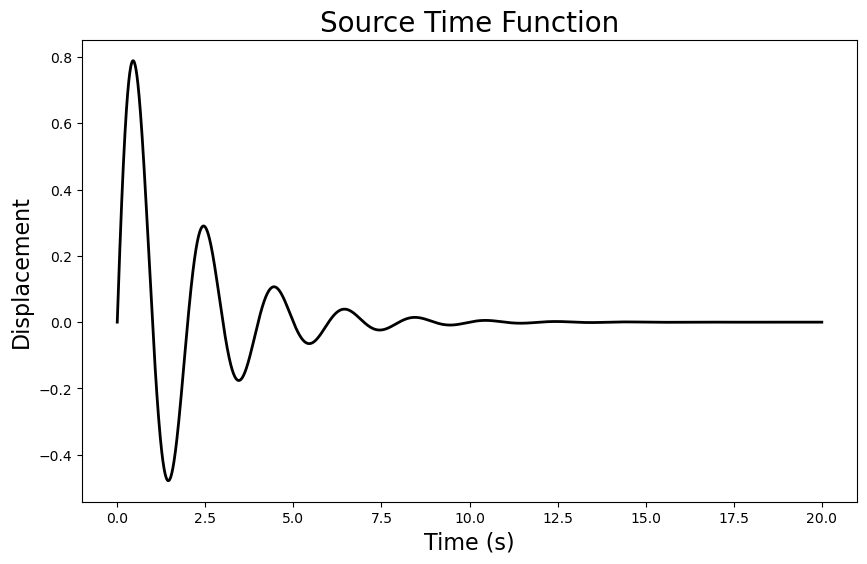

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from Seis import Seismogram
# Plot parameters
title_font,label_font,tick_font,legend_font,line1_width,line2_width = 20,16,12,14,2.0,1.5

# define the elastic parameters
## a: p-wave velocity, b: s-wave velocity, rho: density
a,b,rho=4,3,2.7*10**3

# define the source function
a0,w0= 0.5 , np.pi
def Xt(t,a0=a0,w0=w0):
    t=np.asarray(t,dtype=float)
    Xt_value=np.zeros_like(t)
    Xt_value[t>=0]=np.exp(-a0*t[t>=0])*np.sin(w0*t[t>=0])
    return Xt_value

def Ht(t):
    t=np.asarray(t,dtype=float)
    Ht_value=np.zeros_like(t)
    Ht_value[t>=0]=1
    return Ht_value

t_s=np.linspace(0,20,3000)
Ds=Xt(t_s)
plt.figure(figsize=(10,6))
plt.plot(t_s,Ds,'k-',linewidth=line1_width)
plt.xlabel('Time (s)',fontsize=label_font)
plt.ylabel('Displacement',fontsize=label_font)
plt.title('Source Time Function',fontsize=title_font)
# plt.savefig('Source.png',dpi=300)
plt.show()

## Part 2: Synthetic Seismograms

Compute waveforms at various epicentral distances.

### `Seismogram` Class

Initialize with: `Seis = Seismogram(Xt, a, b, rho)`

| Method | Call | Output |
|:---|:---|:---|
| Radial displacement | `Seis.ur(theta, r, t)` | $u_r(r,\theta,t)$ |
| Angular displacement | `Seis.utheta(theta, r, t)` | $u_\theta(r,\theta,t)$ |

**Parameters:** `theta` (azimuth angle), `r` (epicentral distance), `t` (time array)

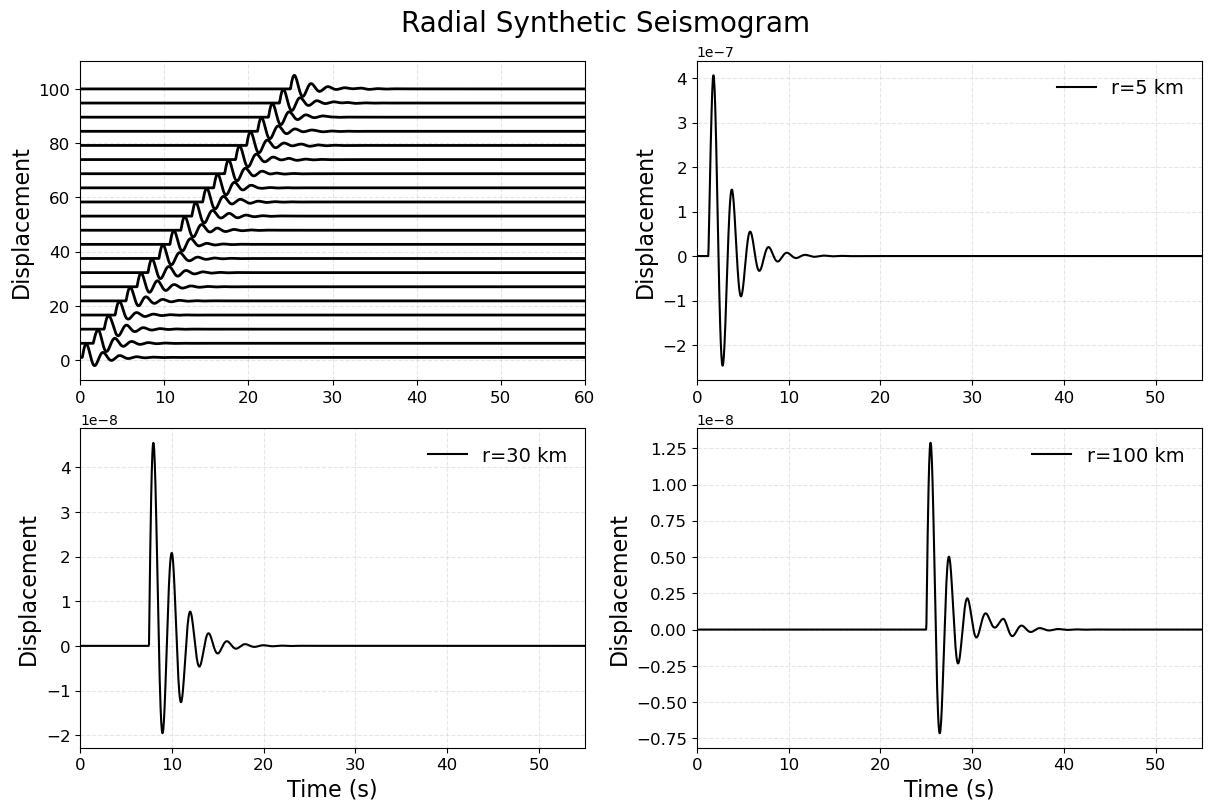

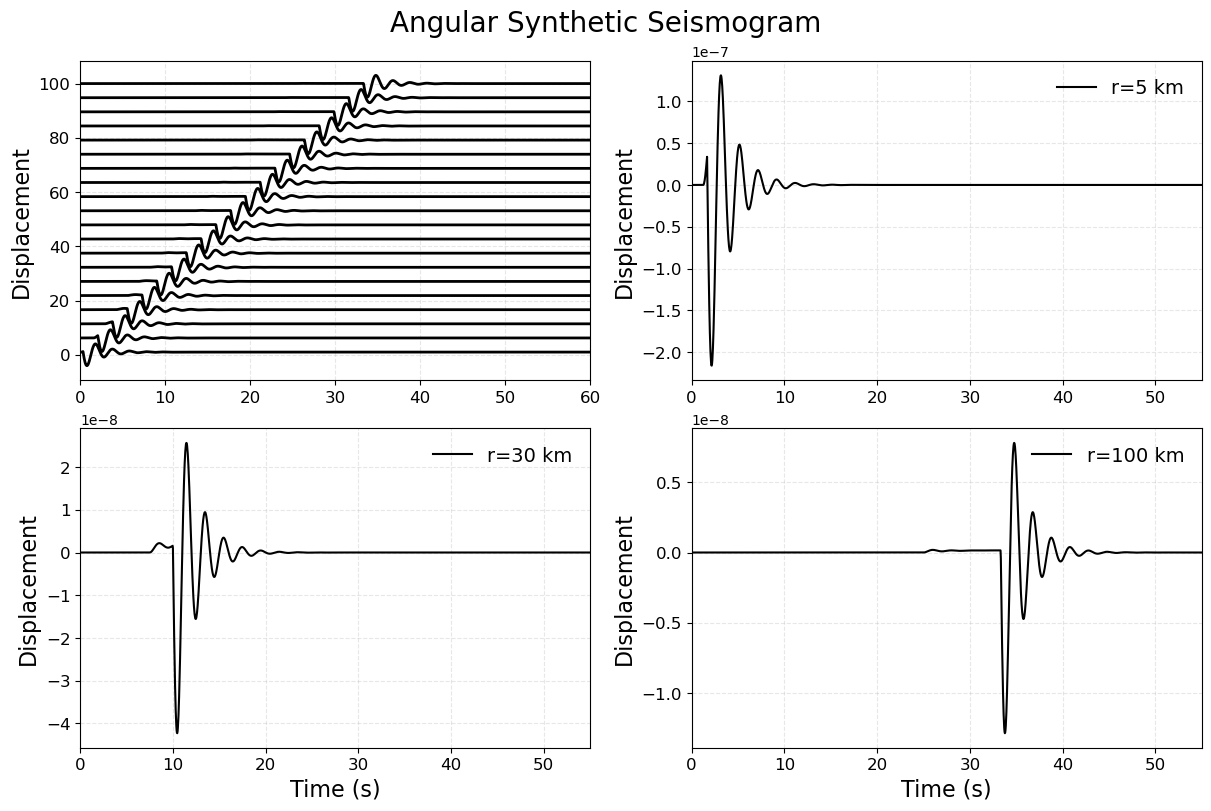

In [ ]:
Seis=Seismogram(Xt,a,b,rho)
r=[5,30,100]
theta=np.array([np.pi/6])
t=np.linspace(0,100,3000)
ur1=Seis.ur(theta,r[0],t)
ur2=Seis.ur(theta,r[1],t)
ur3=Seis.ur(theta,r[2],t)
data_r=[ur1,ur2,ur3]

ut1=Seis.utheta(theta,r[0],t)
ut2=Seis.utheta(theta,r[1],t)
ut3=Seis.utheta(theta,r[2],t)
data_t=[ut1,ut2,ut3]

distache=np.linspace(1,100,20)
ur_distache=np.zeros((len(distache),len(t)))
ut_distache=np.zeros((len(distache),len(t)))
for ii in range(len(distache)):
    ur_distache[ii]=np.squeeze(Seis.ur(theta,distache[ii],t))
    ut_distache[ii]=np.squeeze(Seis.utheta(theta,distache[ii],t))

fig,axes=plt.subplots(2,2,figsize=(12,8),layout='constrained')
fig.suptitle('Radial Synthetic Seismogram',fontsize=title_font)
for ii in range(len(distache)):
    scale=np.max(np.abs(ur_distache[ii]))
    if scale>0:
        axes[0,0].plot(t,5*ur_distache[ii]/scale+distache[ii],'k',linewidth=line1_width)
axes[0,0].set_ylabel('Displacement',fontsize=label_font)
axes[0,0].grid(True,alpha=0.3,linestyle='--')
axes[0,0].tick_params(axis='both',labelsize=tick_font)
axes[0,0].set_xlim(0,60)

for ax,di,ri in zip(axes.flat[1:],data_r,r):
    ax.plot(t,di,'k-',linewidth=line2_width,label=f'r={ri} km')
    ax.set_ylabel('Displacement',fontsize=label_font)
    ax.legend(frameon=False,fontsize=legend_font)
    ax.grid(True,alpha=0.3,linestyle='--')
    ax.tick_params(axis='both',labelsize=tick_font)
    ax.set_xlim(0,55)

for ax in axes[-1,:]:
    ax.set_xlabel('Time (s)',fontsize=label_font)
plt.savefig('radial_seismogram.png',dpi=300)
plt.show()

fig,axes=plt.subplots(2,2,figsize=(12,8),layout='constrained')
fig.suptitle('Angular Synthetic Seismogram',fontsize=title_font)
for ii in range(len(distache)):
    scale=np.max(np.abs(ut_distache[ii]))
    if scale>0:
        axes[0,0].plot(t,5*ut_distache[ii]/scale+distache[ii],'k',linewidth=line1_width)
axes[0,0].set_ylabel('Displacement',fontsize=label_font)
axes[0,0].grid(True,alpha=0.3,linestyle='--')
axes[0,0].tick_params(axis='both',labelsize=tick_font)
axes[0,0].set_xlim(0,60)

for ax,di,ri in zip(axes.flat[1:],data_t,r):
    ax.plot(t,di,'k-',linewidth=line2_width,label=f'r={ri} km')
    ax.set_ylabel('Displacement',fontsize=label_font)
    ax.legend(frameon=False,fontsize=legend_font)
    ax.grid(True,alpha=0.3,linestyle='--')
    ax.tick_params(axis='both',labelsize=tick_font)
    ax.set_xlim(0,55)

for ax in axes[-1,:]:
    ax.set_xlabel('Time (s)',fontsize=label_font)
plt.savefig('angular_seismogram.png',dpi=300)
plt.show()

## Part 3: Radiation Pattern

### Part 3.1: Polar Plot

Plot the P-wave and S-wave amplitude radiation patterns at a fixed time and distance.

#### Method

Evaluate displacement amplitudes over a full azimuth range `theta = np.linspace(0, 2π, 1000)` at fixed `r` and `t`, then plot in polar coordinates.

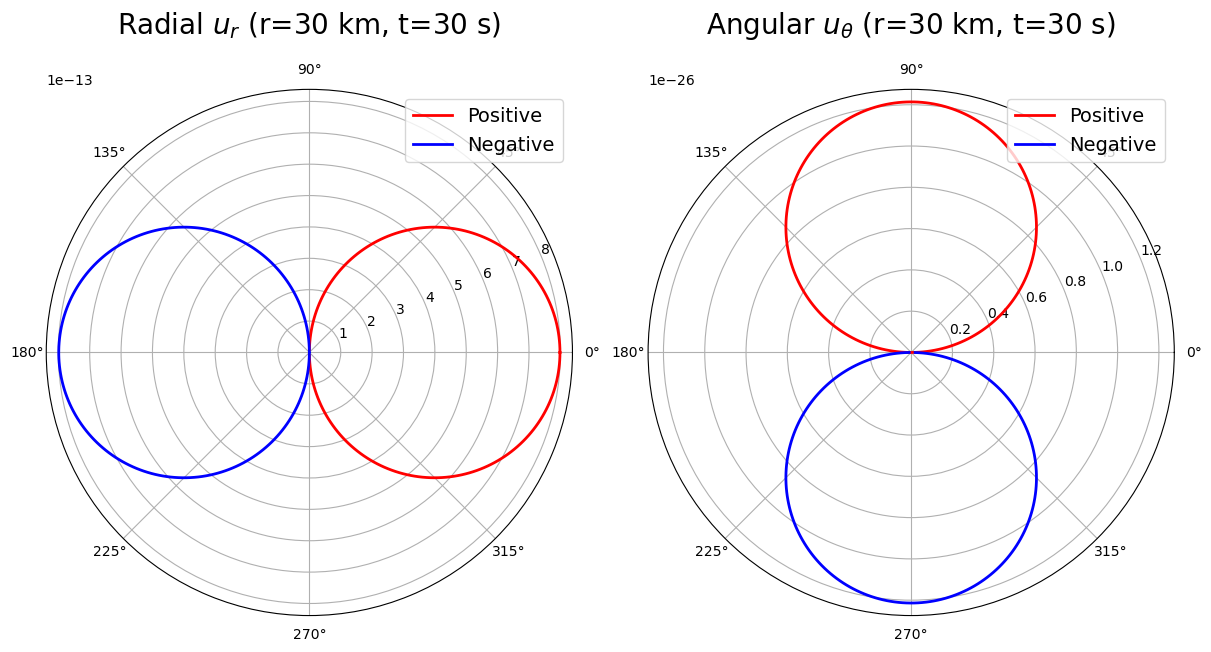

In [21]:
theta = np.linspace(0, 2 * np.pi, 400)
t_fix = 30
r = 30
t = np.array([t_fix])

ur_vals = np.squeeze(Seis.ur(theta, r, t))
ut_vals = np.squeeze(Seis.utheta(theta, r, t))
amp_r = np.abs(ur_vals)
amp_t = np.abs(ut_vals)

fig, axes = plt.subplots(
    1, 2, figsize=(12, 8), layout='constrained',
    subplot_kw=dict(projection='polar'),
)

for ax, vals, amp, name in zip(
    axes,
    [ur_vals, ut_vals],
    [amp_r, amp_t],
    ['Radial $u_r$', 'Angular $u_\\theta$'],
):
    pos = np.where(vals >= 0, amp, np.nan)
    neg = np.where(vals < 0, amp, np.nan)
    ax.plot(theta, pos, color='red', linewidth=line1_width, label='Positive')
    ax.plot(theta, neg, color='blue', linewidth=line1_width, label='Negative')
    ax.set_title(f'{name} (r={r} km, t={t_fix} s)', fontsize=title_font,pad=40)
    ax.set_theta_zero_location('E')
    ax.set_theta_direction(1)
    ax.legend(loc='upper right', fontsize=legend_font)
plt.savefig('Radiation_pattern.png',dpi=300)
plt.show()


### Part 3.2: Azimuthal Record Section

Plot normalized seismograms at different azimuths for a fixed epicentral distance, showing the angular dependence of P- and S-wave arrivals.

#### Method

Loop over `theta = np.arange(-π, π, π/6)` at fixed `r = 30` km, normalize each trace, and stack with azimuth offset.

**Note:** Traces with zero amplitude are plotted as dashed lines, indicating they lie in the neutral plane.

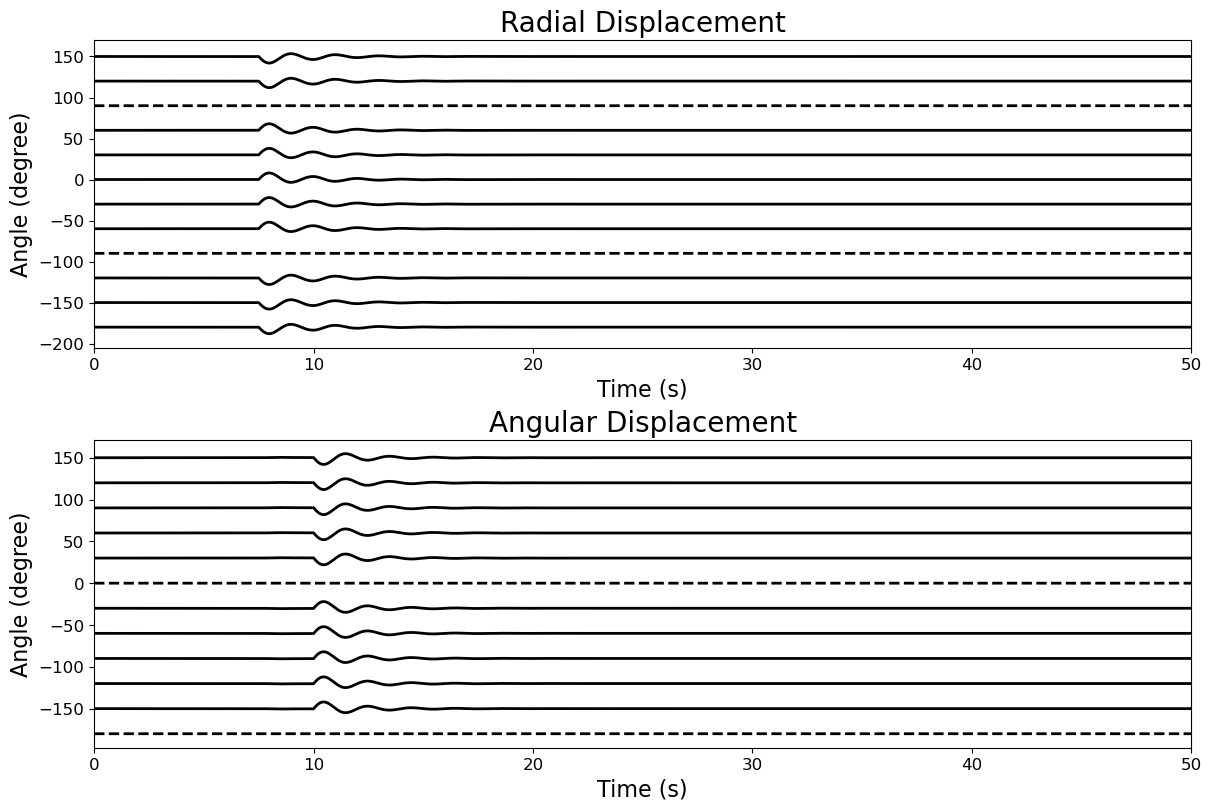

In [16]:
theta = np.arange(-np.pi, np.pi, np.pi / 6)
r = 30
t = np.linspace(0, 100, 3000)
ur = np.zeros((len(theta), len(t)))
ut = np.zeros((len(theta), len(t)))

for ii in range(len(theta)):
    th = np.array([theta[ii]])
    ur[ii] = np.squeeze(Seis.ur(th, r, t))
    ut[ii] = np.squeeze(Seis.utheta(th, r, t))

fig, ax = plt.subplots(2, 1, figsize=(12, 8), layout='constrained')
for ii in range(len(theta)):
    scale = np.max(np.abs(ur[ii]))
    if scale > 0:
        ax[0].plot(t, 8 * ur[ii] / scale + theta[ii] / np.pi * 180,
                   'k-', linewidth=line1_width)
    else:
        ax[0].plot(t,ur[ii]+theta[ii]/np.pi*180,'k--',linewidth=line1_width)
    scale = np.max(np.abs(ut[ii]))
    if scale > 0:
        ax[1].plot(t, 8 * ut[ii] / scale + theta[ii] / np.pi * 180,
                   'k-', linewidth=line1_width)
    else:
        ax[1].plot(t,ut[ii]+theta[ii]/np.pi*180,'k--',linewidth=line1_width)

ax[0].set_xlabel('Time (s)', fontsize=label_font)
ax[0].set_ylabel('Angle (degree)', fontsize=label_font)
ax[0].set_title('Radial Displacement', fontsize=title_font)
ax[0].tick_params(axis='both', labelsize=tick_font)
ax[0].set_xlim(0, 50)
ax[1].set_xlabel('Time (s)', fontsize=label_font)
ax[1].set_ylabel('Angle (degree)', fontsize=label_font)
ax[1].set_title('Angular Displacement', fontsize=title_font)
ax[1].tick_params(axis='both', labelsize=tick_font)
ax[1].set_xlim(0, 50)
plt.savefig('radiation.png',dpi=300)
plt.show()
